# Drag analysis:
Plotting drag coefficient, dimensional analysis and time-series analysis for the six taxa.
### Drag Coefficient:
Plot of mean drag coefficient over the last ten timesteps for all taxa
### Dimensional analysis:
Created 26/02/2026
To assess the importance of drag reduction of spiral patterning on stability, dimensional analysis was used. For a given object of homogeneous material properties, if the drag force $F_d$ is assumed to be producing a torque on the centre of mass, the normal contact force, equal to the weight of the object $G'$, has to act a distance $x$ away from the centre line to produce an opposing torque to balance it. Balancing moments about the centre of mass,

$\tau_d = rF_d = xF_N$

$=> x = \frac{rF_d}{G'} = \frac{r\rho_wC_dAU_0^2}{2f_{calcite}Vg(\rho_{calcite}-\rho_w)}$

which is simply

$x = rW$

where W is the dimensionless ratio of drag and weight.If $x>R$, the radius of the base of the object, the normal contact force moves outside of the object and it will topple over. In other words, if $\frac{x}{R}>1$.

Calculates $\frac{x}{R}$ for a range of $U_0$ and $f_{calcite}$ values (as these are highly uncertain) for the spiral and non-spiral echinoderms.

### Time-series analysis:
Analyses the variation in lateral velocity, $`u_y`$, over time to detect von Kármán vortex shedding and how surpression of this may contribute to reduced drag coefficient. Analysis was conducted with free stream velocity of $`0.1`$ m s $`^{-1}`$.

`time_series.csv` and `FFT.csv` files for each taxon were created manually in paraview (see `time_series_analysis.pvsm` in `[taxon]/velocity/v0.1/postProcessing/`).

In [1]:
# Importing libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import csv

from matplotlib import cm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LinearLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Importing parameters and functions
import parameters as par
import functions as func

In [2]:
# loading taxon objects from parameters.py
taxa = [par.Stromatocystites, par.Kailidiscus, par.Helicocystis_straight, par.Helicocystis, par.Gogia_palmeri, par.Gogia_spiralis]
print("Taxa in analysis:")
for i in taxa:
    print("    - ", i.name)

Taxa in analysis:
    -  stromatocystites
    -  kailidiscus
    -  helicocystis_straight
    -  helicocystis
    -  gogia_palmeri
    -  gogia_spiralis


### Reading in Cd data:

In [3]:
rows = len(taxa)
mean_Cd = np.zeros((rows))
err_Cd = np.zeros((2, rows))
names = []
j = 0
for i in taxa:
    Cd_data = func.read_drag(i.name, i.A_frontal)
    names.append(i.name) 
    mean_Cd[j] = Cd_data["mean"]
    err_Cd[:, j] = Cd_data["error"]
    j += 1

Cd_results = pd.DataFrame({"taxon": names, "mean_Cd": mean_Cd, "err_low": err_Cd[0, :], "err_high": err_Cd[1, :]})
print(Cd_results.dtypes)
print("Cd Data:\n", Cd_results)

taxon           str
mean_Cd     float64
err_low     float64
err_high    float64
dtype: object
Cd Data:
                    taxon   mean_Cd   err_low  err_high
0       stromatocystites  3.137309  0.136201  0.079253
1            kailidiscus  2.565811  0.162214  0.102455
2  helicocystis_straight  3.389739  0.051207  0.042407
3           helicocystis  2.913703  0.036088  0.024399
4          gogia_palmeri  5.030704  0.118163  0.138169
5         gogia_spiralis  4.921996  0.128628  0.174805


### Calculating $x/R$:

In [4]:
xR = []
f_calcite = np.linspace(0.1,0.6,50) # fractional volume of calcite in the organism
#U_0 = np.linspace(0,0.5,50) # range of flow velocities in m/s
U_0_ranges = [0.5,0.5,0.05,0.05,0.1,0.1] # range of flow velocities to calculate x for, depending on taxon.
j = 0
for i in taxa:
    U_0 = np.linspace(0,U_0_ranges[j], 50)
    xR.append(func.calculate_x(i.name, 
              i.A_frontal, 
              i.V, 
              Cd_results.loc[j, "mean_Cd"], 
              i.r, 
              i.R, 
              f_calcite, 
              U_0,
              par.Env1.rho_w,
              par.Env1.g,
              par.Env1.rho_calcite
              )
             )
    j += 1
xR_data = pd.concat(xR)

print("x/R results:\n", xR_data)

x/R results:
                  taxon  f_calcite       U_0        xR
0     stromatocystites        0.1  0.000000  0.000000
1     stromatocystites        0.1  0.010204  0.006311
2     stromatocystites        0.1  0.020408  0.025245
3     stromatocystites        0.1  0.030612  0.056802
4     stromatocystites        0.1  0.040816  0.100981
...                ...        ...       ...       ...
2495    gogia_spiralis        0.6  0.091837  6.521212
2496    gogia_spiralis        0.6  0.093878  6.814264
2497    gogia_spiralis        0.6  0.095918  7.113757
2498    gogia_spiralis        0.6  0.097959  7.419690
2499    gogia_spiralis        0.6  0.100000  7.732064

[15000 rows x 4 columns]


### Reading FFT data:

In [5]:
stromato_FFT = func.calc_FFT(par.Stromatocystites.name, 'probe_0.15_0.06_0.015.csv', par.Stromatocystites.L)
kaili_FFT = func.calc_FFT(par.Kailidiscus.name, 'probe_0.15_0.06_0.015.csv', par.Kailidiscus.L)


Peak occurs at : 0.87890625  Hz
Peak occurs at : 0.09765625  Hz


### Creating figure:
Left column with $C_d$ data, middle column with $x/R$ data and right column with FFT data.

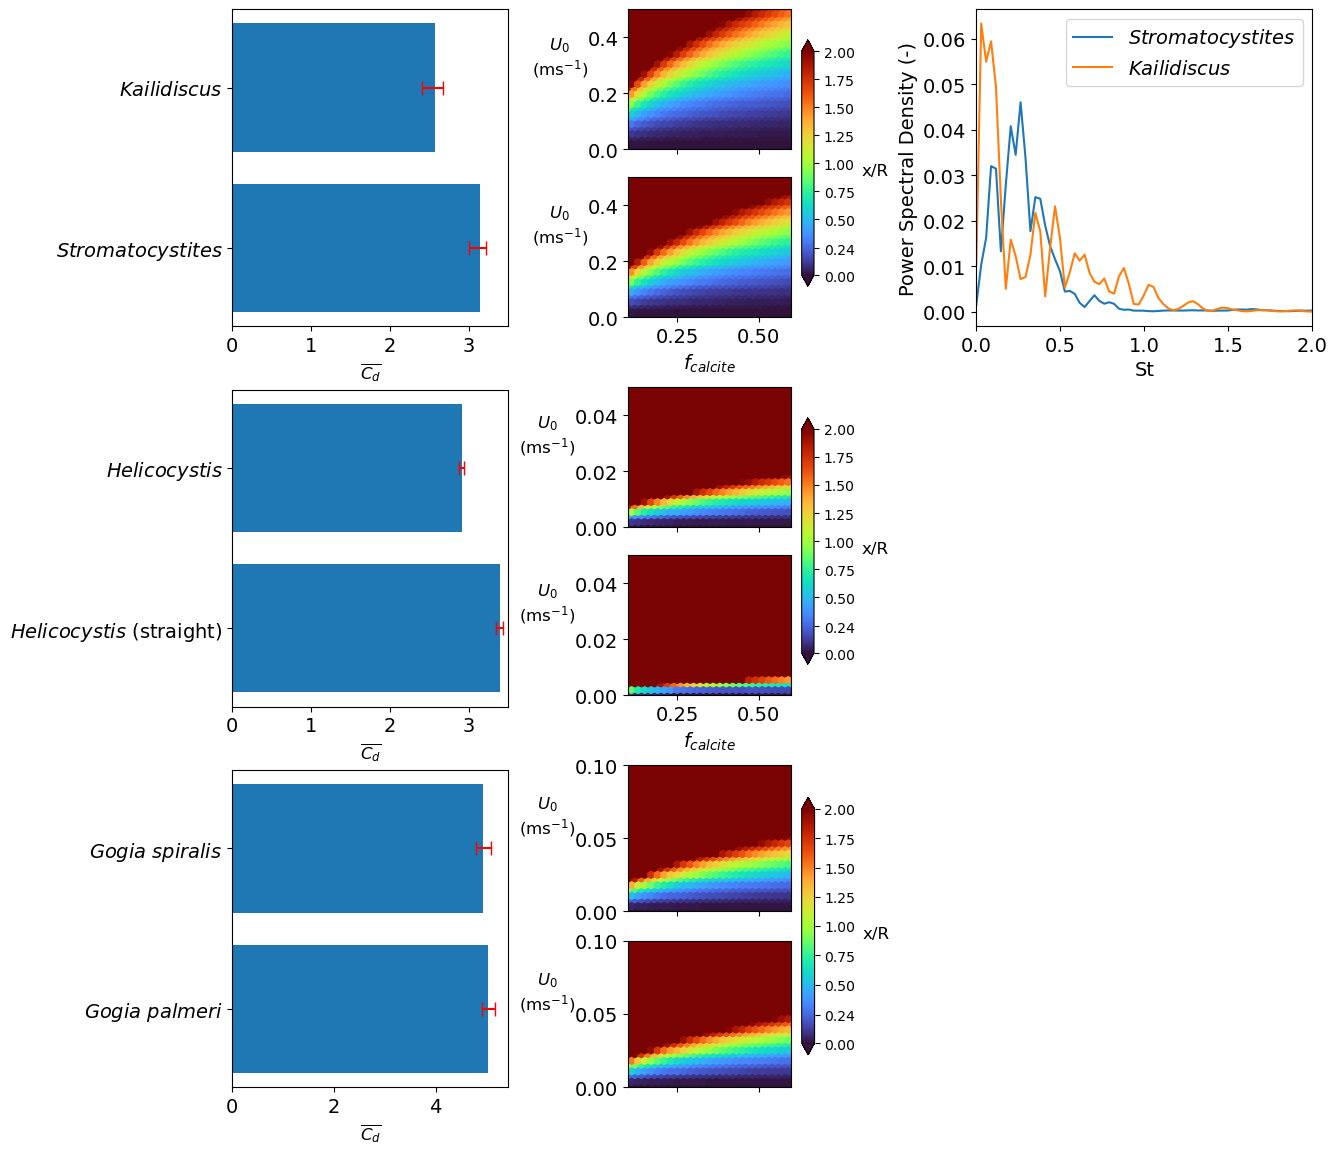

In [11]:
fig = plt.figure()
fig.set_figheight(14)
fig.set_figwidth(12)
plt.rcParams.update({"font.size": 14})

########################## Cd plots #################################
gs1 = GridSpec(3, 1, left=0.05, right=0.28)
######### Edrioasteroids
edrio_names = np.array([par.Stromatocystites.label, par.Kailidiscus.label])
edrio_cd_values = np.array([float(Cd_results.iloc[0].loc['mean_Cd']),float(Cd_results.iloc[1].loc['mean_Cd'])])
edrio_cd_err = np.array([
    [float(Cd_results.iloc[0].loc['err_low']),float(Cd_results.iloc[1].loc['err_low'])],
    [float(Cd_results.iloc[0].loc['err_high']),float(Cd_results.iloc[1].loc['err_high'])]
    ])

ax1 = fig.add_subplot(gs1[0, 0])
ax1.set_xlabel(r"$\overline{C_d}$", fontsize=12)
ax1.barh(edrio_names, edrio_cd_values)
ax1.errorbar(edrio_cd_values, edrio_names, xerr=edrio_cd_err, ecolor='red', fmt='none', capsize=5, zorder=2)
ax1.set_xlim(0,3.5)

######### Helicocystis
helico_names = np.array([par.Helicocystis_straight.label, par.Helicocystis.label])
helico_cd_values = np.array([float(Cd_results.iloc[2].loc['mean_Cd']),float(Cd_results.iloc[3].loc['mean_Cd'])])
helico_cd_err = np.array([
    [float(Cd_results.iloc[2].loc['err_low']),float(Cd_results.iloc[3].loc['err_low'])],
    [float(Cd_results.iloc[2].loc['err_high']),float(Cd_results.iloc[3].loc['err_high'])]
    ])

ax2 = fig.add_subplot(gs1[1, 0])
ax2.set_xlabel(r"$\overline{C_d}$", fontsize=12)
ax2.barh(helico_names, helico_cd_values)
ax2.errorbar(helico_cd_values, helico_names, xerr=helico_cd_err, ecolor='red', fmt='none', capsize=5, zorder=2)
ax2.set_xlim(0,3.5)

######### Gogiids
gogiid_names = np.array([par.Gogia_palmeri.label, par.Gogia_spiralis.label])
gogiid_cd_values = np.array([float(Cd_results.iloc[4].loc['mean_Cd']),float(Cd_results.iloc[5].loc['mean_Cd'])])
gogiid_cd_err = np.array([
    [float(Cd_results.iloc[4].loc['err_low']),float(Cd_results.iloc[5].loc['err_low'])],
    [float(Cd_results.iloc[4].loc['err_high']),float(Cd_results.iloc[5].loc['err_high'])]
    ])

ax3 = fig.add_subplot(gs1[2, 0])
ax3.set_xlabel(r"$\overline{C_d}$", fontsize=12)
ax3.barh(gogiid_names, gogiid_cd_values)
ax3.errorbar(gogiid_cd_values, gogiid_names, xerr=gogiid_cd_err, ecolor='red', fmt='none', capsize=5, zorder=2)
#ax3.set_xlim(0,3.5)

########################## xR plots #################################
######### Edrioasteroids
gs2 = GridSpec(2, 1, left=0.38, right=0.55, bottom=0.66, hspace=0.2)
# Kailidiscus:
ax4 = fig.add_subplot(gs2[0, 0])
ax4.tick_params(labelbottom=False)
ax4.set_ylabel(r"$U_0$" "\n" "(ms$^{-1}$)", rotation=0, fontsize=12, labelpad = 20)
# Configuring colormap:
cmap = plt.get_cmap('turbo')
vmin = xR_data.query('taxon == "stromatocystites"')["xR"].min()
vmax = 2
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)
hb = ax4.hexbin(xR_data.query('taxon == "kailidiscus"')["f_calcite"], xR_data.query('taxon == "kailidiscus"')["U_0"],
                C=xR_data.query('taxon == "kailidiscus"')["xR"], 
                gridsize=25,
                cmap=cmap, 
                norm=norm
                )
xlim = xR_data.query('taxon == "kailidiscus"')["f_calcite"].min(), xR_data.query('taxon == "kailidiscus"')["f_calcite"].max()
ylim = xR_data.query('taxon == "kailidiscus"')["U_0"].min(), xR_data.query('taxon == "kailidiscus"')["U_0"].max()
ax4.set_xlim(xlim)
ax4.set_ylim(ylim)
# Stromatocystites
ax5 = fig.add_subplot(gs2[1, 0])
ax5.set_ylabel(r"$U_0$" "\n" "(ms$^{-1}$)", rotation=0, fontsize=12, labelpad = 20)
ax5.set_xlabel(r"$f_{calcite}$")
# Stromatocystites:
ax5.hexbin(xR_data.query('taxon == "stromatocystites"')["f_calcite"], xR_data.query('taxon == "stromatocystites"')["U_0"],
                C=xR_data.query('taxon == "stromatocystites"')["xR"], 
                gridsize=25,
                cmap=cmap, 
                norm=norm
                )
xlim = xR_data.query('taxon == "stromatocystites"')["f_calcite"].min(), xR_data.query('taxon == "stromatocystites"')["f_calcite"].max()
ylim = xR_data.query('taxon == "stromatocystites"')["U_0"].min(), xR_data.query('taxon == "stromatocystites"')["U_0"].max()
ax5.set_xlim(xlim)
ax5.set_ylim(ylim)
# Plotting colorbar
cbar = fig.colorbar(hb, ax=[ax4,ax5],
                    location='right', shrink=0.8, extend='both', aspect=20)
cbar.set_label(r'x/R', rotation=0, labelpad=15, fontsize=12)
cbar.set_ticks([0, 0.24, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2])
cbar.ax.tick_params(labelsize=10)

############## Helicocystis
gs3 = GridSpec(2, 1, left=0.38, right=0.55, top = 0.61, bottom=0.39, hspace=0.2)
ax6 = fig.add_subplot(gs3[0, 0])
ax6.tick_params(labelbottom=False)
ax6.set_ylabel(r"$U_0$" "\n" "(ms$^{-1}$)", rotation=0, fontsize=12, labelpad = 20)
ax6.hexbin(xR_data.query('taxon == "helicocystis"')["f_calcite"], xR_data.query('taxon == "helicocystis"')["U_0"],
                C=xR_data.query('taxon == "helicocystis"')["xR"], 
                gridsize=25,
                cmap=cmap, 
                norm=norm
                )
xlim = xR_data.query('taxon == "helicocystis"')["f_calcite"].min(), xR_data.query('taxon == "helicocystis"')["f_calcite"].max()
ylim = xR_data.query('taxon == "helicocystis"')["U_0"].min(), xR_data.query('taxon == "helicocystis"')["U_0"].max()
ax6.set_xlim(xlim)
ax6.set_ylim(ylim)
# Helicocystis straight
ax7 = fig.add_subplot(gs3[1, 0])
ax7.set_ylabel(r"$U_0$" "\n" "(ms$^{-1}$)", rotation=0, fontsize=12, labelpad = 20)
ax7.set_xlabel(r"$f_{calcite}$")
# Configuring colormap:
cmap = plt.get_cmap('turbo')
vmin = xR_data.query('taxon == "helicocystis_straight"')["xR"].min()
vmax = 2
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)
hb = ax7.hexbin(xR_data.query('taxon == "helicocystis_straight"')["f_calcite"], xR_data.query('taxon == "helicocystis_straight"')["U_0"],
                C=xR_data.query('taxon == "helicocystis_straight"')["xR"], 
                gridsize=25,
                cmap=cmap, 
                norm=norm
                )
xlim = xR_data.query('taxon == "helicocystis_straight"')["f_calcite"].min(), xR_data.query('taxon == "helicocystis_straight"')["f_calcite"].max()
ylim = xR_data.query('taxon == "helicocystis_straight"')["U_0"].min(), xR_data.query('taxon == "helicocystis_straight"')["U_0"].max()
ax7.set_xlim(xlim)
ax7.set_ylim(ylim)
# Plotting colorbar
cbar = fig.colorbar(hb, ax=[ax6,ax7],
                    location='right', shrink=0.8, extend='both', aspect=20)
cbar.set_label(r'x/R', rotation=0, labelpad=15, fontsize=12)
cbar.set_ticks([0, 0.24, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2])
cbar.ax.tick_params(labelsize=10)

############## Gogiids
gs4 = GridSpec(2, 1, left=0.38, right=0.55, top = 0.34, hspace=0.2)
# Gogia spiralis
ax8 = fig.add_subplot(gs4[0, 0])
ax8.tick_params(labelbottom=False)
ax8.set_ylabel(r"$U_0$" "\n" "(ms$^{-1}$)", rotation=0, fontsize=12, labelpad = 20)
ax8.hexbin(xR_data.query('taxon == "gogia_spiralis"')["f_calcite"], xR_data.query('taxon == "gogia_spiralis"')["U_0"],
                C=xR_data.query('taxon == "gogia_spiralis"')["xR"], 
                gridsize=25,
                cmap=cmap, 
                norm=norm
                )
xlim = xR_data.query('taxon == "gogia_spiralis"')["f_calcite"].min(), xR_data.query('taxon == "gogia_spiralis"')["f_calcite"].max()
ylim = xR_data.query('taxon == "gogia_spiralis"')["U_0"].min(), xR_data.query('taxon == "gogia_spiralis"')["U_0"].max()
ax8.set_xlim(xlim)
ax8.set_ylim(ylim)
# Gogia palmeri
ax9 = fig.add_subplot(gs4[1, 0])
ax9.tick_params(labelbottom=False)
ax9.set_ylabel(r"$U_0$" "\n" "(ms$^{-1}$)", rotation=0, fontsize=12, labelpad = 20)
# Configuring colormap:
cmap = plt.get_cmap('turbo')
vmin = xR_data.query('taxon == "helicocystis_straight"')["xR"].min()
vmax = 2
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)
hb = ax9.hexbin(xR_data.query('taxon == "gogia_palmeri"')["f_calcite"], xR_data.query('taxon == "gogia_palmeri"')["U_0"],
                C=xR_data.query('taxon == "gogia_palmeri"')["xR"], 
                gridsize=25,
                cmap=cmap, 
                norm=norm
                )
xlim = xR_data.query('taxon == "gogia_palmeri"')["f_calcite"].min(), xR_data.query('taxon == "gogia_palmeri"')["f_calcite"].max()
ylim = xR_data.query('taxon == "gogia_palmeri"')["U_0"].min(), xR_data.query('taxon == "gogia_palmeri"')["U_0"].max()
ax9.set_xlim(xlim)
ax9.set_ylim(ylim)
# Plotting colorbar
cbar = fig.colorbar(hb, ax=[ax8,ax9],
                    location='right', shrink=0.8, extend='both', aspect=20)
cbar.set_label(r'x/R', rotation=0, labelpad=15, fontsize=12)
cbar.set_ticks([0, 0.24, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2])
cbar.ax.tick_params(labelsize=10)

########################## FFT plots #################################
gs5 = GridSpec(3, 1, left=0.67, right=0.95)

######### Edrioasteroids
ax10 = fig.add_subplot(gs5[0, 0])
ax10.plot(stromato_FFT['strouhal'], stromato_FFT['psd'], label=par.Stromatocystites.label)
ax10.plot(kaili_FFT['strouhal'], kaili_FFT['psd'], label=par.Kailidiscus.label)
ax10.set_xlabel("St")
ax10.set_ylabel("Power Spectral Density (-)")
ax10.set_xlim(0,2)
ax10.legend()

plt.savefig('figures/drag_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()